In [6]:
# Imports
from  Rolling_Intrinsic_Forecast_QH import run_optimization_quarterhours_repositioning, get_net_trades #,load_real_data, get_average_prices_w_forecast
import os
import pandas as pd
from loguru import logger
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Ellipse
import matplotlib.dates as mdates
from pandas._libs.tslibs.parsing import DateParseError
logger.remove()
df_CID = pd.read_parquet("../../id_prices.parquet")

***

# Task: Build a new VWAP function for forecast based approach: 



requirements: 
- calculates VWAP based on past x transactions
- uses forecasted prices to for products more than 5 hours away
- Similar to model predictive control:
  - Only initiates trades for next 45 mins (build from scratch) 

## VWAP of Forecast +  Latest transactions

### Discussion

Requires the merging of price curves such that all prices beyond 5 hours from current time step are predicated on DAM prices.
Give 2 Dataframes as input for VWAP
1.  CID data
2.  DAM data from the same time frame as CID data
    1.  On ENTSOE - Website you can get:
        1.  EPEX SDAC Day Ahead Auction results with 15min resolution instead of 1 hour!
        2.  Use Sequence 1 from csv
3.  adapt get_average_prices function

### Implementation

In [7]:
df_CID.head()

,side,product,deliverystart,deliveryend,tradephase,price,volume
executiontime,,,,,,,
2025-01-31 15:01:38.603000+01:00,BUY,XBID_Quarter_Hour_Power,2025-02-01 06:45:00+01:00,2025-02-01 07:00:00+01:00,CONT,121.40,0.200
2025-01-31 15:01:38.603000+01:00,SELL,XBID_Quarter_Hour_Power,2025-02-01 06:45:00+01:00,2025-02-01 07:00:00+01:00,CONT,121.40,0.200
2025-01-31 15:01:38.837000+01:00,BUY,XBID_Quarter_Hour_Power,2025-02-01 07:45:00+01:00,2025-02-01 08:00:00+01:00,CONT,141.59,0.150
2025-01-31 15:01:38.837000+01:00,SELL,XBID_Quarter_Hour_Power,2025-02-01 07:45:00+01:00,2025-02-01 08:00:00+01:00,CONT,141.59,0.150
2025-01-31 15:01:39.059000+01:00,BUY,XBID_Quarter_Hour_Power,2025-02-01 08:00:00+01:00,2025-02-01 08:15:00+01:00,CONT,129.52,0.025


Use DAM data as "Forecast Data"

In [8]:
#Import DAM data
df_forecast = pd.read_csv("../../2025_SDAC_auction_results.csv")
df_forecast = df_forecast[df_forecast.Sequence=="Sequence Sequence 1"]
df_forecast = df_forecast.loc[:,['MTU (CET/CEST)','Day-ahead Price (EUR/MWh)']].reset_index(drop=True)
df_forecast.columns=["product","price"]
def ret_deliverystartend(deliverystart:str):
    start,end = deliverystart.split(" - ")
    return start,end
def check_set_dt(ts:str):
    try:
        ts = pd.to_datetime(ts,dayfirst=True,format="mixed")\
            .tz_localize(tz="Europe/Berlin")
    except DateParseError as e:
        print(e,"\nChecking if CET or CEST included in string")
        if ts.endswith("(CET)") or ts.endswith("(CEST)") :
            ts = ts.replace("(CET)","")
            ts = ts.replace("(CEST)","")
            pd.to_datetime(ts,dayfirst=True,format="mixed")\
                .tz_localize(tz="Europe/Berlin")
            print(f"error resolved for {ts}")
        else :
            print("Error unresolved, replacing timestap with NAN")
            ts = np.nan
    return ts
df_temp = pd.DataFrame.from_records(df_forecast["product"].apply(ret_deliverystartend),
                          columns=["deliverystart","deliveryend"])
df_forecast = df_temp.join(df_forecast).drop(["product","deliveryend"],axis=1)
df_forecast["deliverystart"] = df_forecast.deliverystart.apply(check_set_dt)
df_forecast.set_index("deliverystart",inplace=True)
df_forecast.head()  


Unknown datetime string format, unable to parse: 30/03/2025 01:45:00 (CET), at position 0 
Checking if CET or CEST included in string
error resolved for 30/03/2025 01:45:00 
Unknown datetime string format, unable to parse: 30/03/2025 03:00:00 (CEST), at position 0 
Checking if CET or CEST included in string
error resolved for 30/03/2025 03:00:00 


,price
deliverystart,
2025-01-01 00:00:00+01:00,2.16
2025-01-01 00:15:00+01:00,2.16
2025-01-01 00:30:00+01:00,2.16
2025-01-01 00:45:00+01:00,2.16
2025-01-01 01:00:00+01:00,1.60


### Write the VWAP Function

In [30]:
def get_average_prices_w_forecast(
    df_forecast,
    df_CID,side, 
    execution_time_start, 
    execution_time_end, 
    end_date, 
    min_trades=10
    ):
    # set start_of_day to end_date minus 1 day
    start_of_day = (pd.to_datetime(end_date) - pd.Timedelta(hours=2))


    # set hour and minute to 0 (europe/berlin time)
    start_of_day = start_of_day.replace(hour=0, minute=0)
    end_of_day = start_of_day
    end_of_day = end_of_day.replace(hour=23, minute=45)


    df_bucket = df_CID.loc[execution_time_start :execution_time_end,:].copy()
    # Only take executed trades within bucket, and with deilvery period of selected day
    filter = (df_bucket.side==side) &\
             (df_bucket.deliverystart < end_date) &\
             (df_bucket.deliverystart >= start_of_day) 
            

    df_bucket = df_bucket[filter]

    result = df_bucket.groupby("deliverystart",as_index=False).filter(lambda x: len(x)>=min_trades)
    ###################### Only keep the last 4 executed trades of any product#######################
    result = result.groupby("deliverystart",as_index=False).apply(lambda x: x.tail(4))
    
    ###################################################################################################
    #print(result)
    result = result.groupby("deliverystart",as_index=False)\
          .apply(func = (lambda x: (x.price * x.volume).sum() / x.volume.sum()))
   
    if result.shape[0]>0:
          df_vwap = pd.DataFrame(result.values, columns=["product", "price"])
    else:
         return pd.DataFrame(np.array([[np.nan,np.nan],[np.nan,np.nan]]), columns=["product", "price"])
    df_vwap = df_vwap.astype({ "price" : "float64"})
    # set index to product
    df_vwap.set_index("product", inplace=True)
    
    # set index to be all 15 minute intervals from start_of_day to end_of_day, filling missing values with NaN
    df_vwap = df_vwap.reindex(pd.date_range(start_of_day, end_of_day, freq="15min"))

    #-------------------------RECHECK THE LOGIC HERE-------------------------
    if (execution_time_end + pd.Timedelta(hours=5)) < start_of_day:
      include_forecast = start_of_day
    # if executiontime + 5 hours are within the deliveryday,then 
    else:  
      include_forecast = execution_time_end + pd.Timedelta(hours=5)
    vwap_price = df_vwap.loc[:include_forecast]#.iloc[:-2]
    # Don't include the end date
    forecast_price = df_forecast.loc[vwap_price.index[-1]:
                                     start_of_day.replace(hour=23,minute=45,second=0)]\
                                      .iloc[1:]
    #---------------------------------------------------------------------------
    df_vwap_w_forecast = pd.concat([vwap_price, forecast_price],axis=0)  
    #logger.debug("\n"+"."*50 + "This is the VWAP" + "."*50 + "\n" + df_vwap.to_string())


    ##### Only for Comparison , can be deleted later###############################################
    df_old_vwap = df_bucket.groupby("deliverystart",as_index=False).filter(lambda x: len(x)>=min_trades)\
      .groupby("deliverystart",as_index=False)\
      .apply(func = (lambda x: (x.price * x.volume).sum() / x.volume.sum())) 
    if df_old_vwap.shape[0]>0:
          df_old_vwap = pd.DataFrame(df_old_vwap.values, columns=["product", "price"])
    else:
         return pd.DataFrame(np.array([[np.nan,np.nan],[np.nan,np.nan]]), columns=["product", "price"])
    df_old_vwap.set_index("product", inplace=True)
    df_old_vwap = df_old_vwap.reindex(pd.date_range(start_of_day, end_of_day, freq="15min"))
    ##############################################################################################
    return df_old_vwap, df_vwap_w_forecast



In [31]:
#"2025-02-05 17:00:00+01:00" : "2025-02-05 17:15:00+01:00" causes a problem. Check for errors and investigate more !
execution_time_start = pd.Timestamp("2025-02-04 23:45:00",tz='Europe/Berlin') 
execution_time_end = pd.Timestamp("2025-02-05 00:00:00",tz='Europe/Berlin')
end_date = pd.Timestamp("2025-02-06 00:00:00",tz='Europe/Berlin')
min_trades=5
# This curve is fine, the problem is the optimisation run!
vwap,vwap_forecast = get_average_prices_w_forecast(df_forecast,
                              df_CID,"BUY",
                              execution_time_start,
                              execution_time_end,
                              end_date)


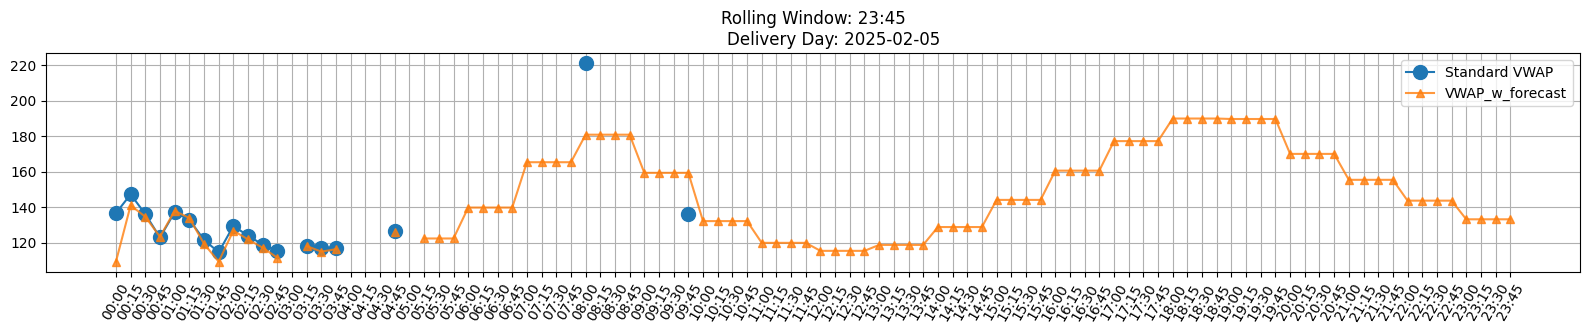

In [34]:
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(16, 3))

ax.plot(vwap["price"], label="Standard VWAP", marker="o",markersize=10)
ax.plot(vwap_forecast["price"], label="VWAP_w_forecast", marker="^",alpha=0.8)

x_ticks = pd.date_range(
    start=vwap.index[0],
    end=vwap_forecast.index[-1],
    freq="15min"
)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks.strftime("%H:%M"), rotation=60)
ax.grid(True)

ax.legend()
plt.tight_layout()

ax.set_title(f"""Rolling Window: {execution_time_start.strftime("%H:%M")}
        Delivery Day: {vwap.index[0].date()}""" )
plt.show()


### Test the method and daily profits below!

Bucket starts 2025-02-05 16:00:00+01:00 : 2025-02-05 16:15:00+01:00
Bucket starts 2025-02-05 16:15:00+01:00 : 2025-02-05 16:30:00+01:00
Bucket starts 2025-02-05 16:30:00+01:00 : 2025-02-05 16:45:00+01:00
Bucket starts 2025-02-05 16:45:00+01:00 : 2025-02-05 17:00:00+01:00

              execution_time  side  quantity   price                   product  \
0 2025-02-05 17:00:00+01:00   buy      1.00  123.99 2025-02-06 03:45:00+01:00   
1 2025-02-05 17:00:00+01:00  sell      0.85  210.71 2025-02-06 09:00:00+01:00   

      profit  
0 -30.997500  
1  44.775875  
Bucket starts 2025-02-05 17:00:00+01:00 : 2025-02-05 17:15:00+01:00


ValueError: 'deliverystart' is both an index level and a column label, which is ambiguous.

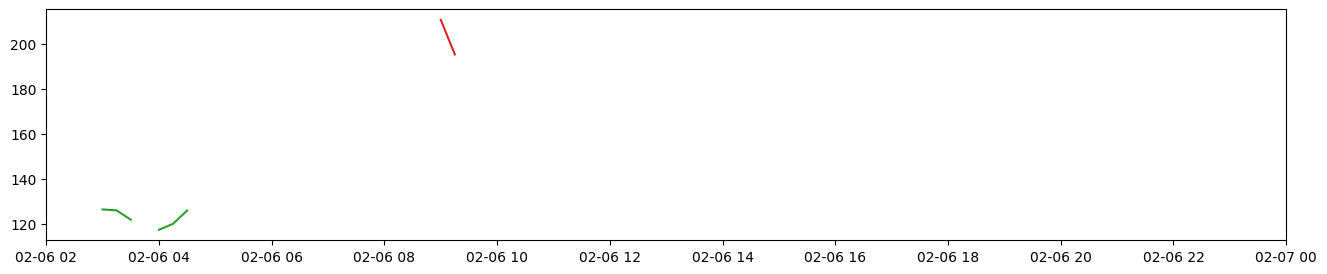

In [24]:
## Adapt initiate trades function
### Battery Param-
threshold=0
threshold_abs_min=0
discount_rate=0
bucket_size=10
c_rate=1
roundtrip_eff=0.85
max_cycles = 1


### Rolling window: The first execution window available for products on the next day is 16:00-16:15!

execution_time_start = pd.Timestamp("2025-02-05 16:00:00",tz='Europe/Berlin') 
execution_time_end = pd.Timestamp("2025-02-05 16:15:00",tz='Europe/Berlin')
end_date = pd.Timestamp("2025-02-07 00:00:00",tz='Europe/Berlin')
min_trades=5
net_trades = get_net_trades(trades = pd.DataFrame(columns=["sum_buy", "sum_sell", "net_buy", "net_sell", "product"]),
                            end_date = end_date)
all_trades = pd.DataFrame(
                columns=["execution_time", "side", "quantity", "price", "product", "profit"]
            )
fig,ax = plt.subplots(1,1,figsize=(16,3))
for ts in pd.date_range(start=execution_time_start,end=execution_time_start+pd.Timedelta("23hour"),freq="15min"):
    ts_start = ts
    ts_end = ts + pd.Timedelta("15min")
    print(f"Bucket starts {ts_start} : {ts_end}")
    vwap,vwap_forecast = get_average_prices_w_forecast(df_forecast,
                              df_CID,"BUY",
                              ts_start,
                              ts_end,
                              end_date)
    # All products must be atleast 15 minutes ahead of the bucket close so trades can still be made
    lead_time = ts_end + pd.Timedelta("15min")

    ax.plot(vwap.loc[lead_time:].index,
            vwap.loc[lead_time:],
            label=ts_end)

    results, trades, profit = run_optimization_quarterhours_repositioning(
                                                prices_qh = vwap[lead_time:].copy(),
                                                execution_time = ts_end,
                                                cap = 1,
                                                c_rate = c_rate,
                                                roundtrip_eff = roundtrip_eff,
                                                max_cycles = max_cycles,
                                                threshold = threshold,
                                                threshold_abs_min = 0,
                                                discount_rate = 0,
                                                prev_net_trades = get_net_trades(all_trades, end_date=end_date)
                                                )
    #only execute trades with delivery in next 45 minutes
    #include_trades = trades["product"] < execution_time_end + pd.Timedelta(hours=3,minutes=0,seconds=0)
    #trades = trades[include_trades]
    if trades.shape[0]>0:
        print(f"\n {trades}")
    all_trades = pd.concat([all_trades, trades])
all_trades
ax.legend(loc="best")

In [110]:
net_trades = get_net_trades(all_trades, end_date=end_date)
net_trades[(net_trades.sum_buy>0) | (net_trades.sum_sell>0)]

,sum_buy,sum_sell,net_buy,net_sell
2025-02-04 00:45:00+01:00,1.000000,0.000000,1.0,0.0
2025-02-04 01:00:00+01:00,1.000000,0.000000,1.0,0.0
2025-02-04 01:15:00+01:00,1.000000,0.000000,1.0,0.0
2025-02-04 01:30:00+01:00,0.338609,0.338609,0.0,0.0
2025-02-04 01:45:00+01:00,1.338609,1.338609,0.0,0.0
...,...,...,...,...
2025-02-04 21:45:00+01:00,2.000000,2.000000,0.0,0.0
2025-02-04 22:00:00+01:00,1.700000,1.700000,0.0,0.0
2025-02-04 22:45:00+01:00,2.000000,2.000000,0.0,0.0
2025-02-04 23:00:00+01:00,2.700000,2.700000,0.0,0.0


In [111]:
all_trades

,execution_time,side,quantity,price,product,profit
0,2025-02-04 00:00:00+01:00,buy,1.000000,119.25,2025-02-04 00:45:00+01:00,-29.812500
1,2025-02-04 00:00:00+01:00,buy,0.338609,122.17,2025-02-04 01:45:00+01:00,-10.341970
2,2025-02-04 00:00:00+01:00,buy,1.000000,121.28,2025-02-04 02:45:00+01:00,-30.320000
3,2025-02-04 00:00:00+01:00,buy,1.000000,119.95,2025-02-04 04:00:00+01:00,-29.987500
4,2025-02-04 00:00:00+01:00,buy,1.000000,116.16,2025-02-04 05:00:00+01:00,-29.040000
...,...,...,...,...,...,...
0,2025-02-04 22:30:00+01:00,sell,1.000000,119.11,2025-02-04 22:45:00+01:00,29.777500
1,2025-02-04 22:30:00+01:00,buy,1.850000,116.51,2025-02-04 23:00:00+01:00,-53.885875
2,2025-02-04 22:30:00+01:00,sell,0.850000,137.65,2025-02-04 23:15:00+01:00,29.250625
0,2025-02-04 22:45:00+01:00,sell,1.000000,134.67,2025-02-04 23:00:00+01:00,33.667500


In [112]:
all_trades.profit.sum()

np.float64(-952.9850402592301)

In [ ]:

prof=pd.read_csv("../../Dashboard/demo_output/forecast_based/quarterhourly/bs15cr1rto0.85mc30.416666666666668mt5/trades/trades_2025-02-01.csv")
prof.profit.sum()

np.float64(217.84004991731044)

### Discussion

The __run_optimization_quarterhours_repositioning__ function in the simulation returns 3 objects:
|Object|explanation|
|------|------------|
|results| explained in cell below|
|trades| all trades that are to be executed in the current rolling window|
|profits|soln of maximisation problem|





$$
\text{for each } i \text{ in products:}
$$

$$
\begin{aligned}
\text{results.loc}[i,\,\text{"current\_buy\_qh"}] &\leftarrow \text{current\_buy\_qh}[i].\text{value()} \\
\text{results.loc}[i,\,\text{"current\_sell\_qh"}] &\leftarrow \text{current\_sell\_qh}[i].\text{value()} \\
\text{results.loc}[i,\,\text{"net\_buy"}] &\leftarrow \text{net\_buy}[i].\text{value()} \\
\text{results.loc}[i,\,\text{"net\_sell"}] &\leftarrow \text{net\_sell}[i].\text{value()} \\
\text{results.loc}[i,\,\text{"charge\_sign"}] &\leftarrow \text{charge\_sign}[i].\text{value()} \\
\text{results.loc}[i,\,\text{"battery\_soc"}] &\leftarrow \text{battery\_soc}[i].\text{value()}
\end{aligned}
$$



__**Goal:**__  
To accomplish an approach similar to model predictive control, one must ensure that the all the returned results,trades and profits are only applied upto a certain time.
> ⚠️**Example:** Lets say that the optimal trades were returned for the rest of the day, we will only execute the trades for the products with delivery time in the next hour, instead of all the product.  

The reason being that the products further away are not liquid, thus we would be wasting BESS capacity since we are making decisions based on incomplete information  



__**Implementation:**__   
|Object|Implementation|
|-------|-------------|
|Result|Never Accessed by simulation function   |
|Trades|Used by simulation function to calculate daily profits  |
|Profit|Never accessed within the simulation    |

Therefore it should be simple to implement a new function called : __MPC_simulate_priod__  
where the returned trades period is overwritten and **every trade after 45 minutes from current time is dropped** from the dataframe. Nothing else changes 


### Implementation